### 📂 Google Drive Bağlantısı
Veri dosyalarını kullanmak için Drive bağlanır.



In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2) Veri Yükleme

## 📄 Temizlenmiş Eğitim Verisinin Yüklenmesi
train_clean_final dosyası Google Drive içinden okunur.



In [42]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/train_clean_final (2).csv")
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,weekday,month,is_weekend,haversine_km
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3,0,1.498521
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6,1,1.805507
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1,0,6.385098
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,4,0,1.485498
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,3,1,1.188588


3) Temel İnceleme (info + describe)
### 🔍 Veri Setinin Yapısının İncelenmesi
Temel istatistikler ve veri bilgisi görüntülenir.


In [43]:
df.info()
df.describe().T



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1447628 entries, 0 to 1447627
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1447628 non-null  object 
 1   vendor_id           1447628 non-null  int64  
 2   pickup_datetime     1447628 non-null  object 
 3   dropoff_datetime    1447628 non-null  object 
 4   passenger_count     1447628 non-null  int64  
 5   pickup_longitude    1447628 non-null  float64
 6   pickup_latitude     1447628 non-null  float64
 7   dropoff_longitude   1447628 non-null  float64
 8   dropoff_latitude    1447628 non-null  float64
 9   store_and_fwd_flag  1447628 non-null  object 
 10  trip_duration       1447628 non-null  int64  
 11  hour                1447628 non-null  int64  
 12  weekday             1447628 non-null  int64  
 13  month               1447628 non-null  int64  
 14  is_weekend          1447628 non-null  int64  
 15  haversine_km   

,count,mean,std,min,25%,50%,75%,max
vendor_id,1447628.0,1.535053,0.498770,1.000000,1.000000,2.000000,2.000000,2.000000
passenger_count,1447628.0,1.665370,1.314684,1.000000,1.000000,1.000000,2.000000,6.000000
pickup_longitude,1447628.0,-73.973581,0.037794,-74.233780,-73.991875,-73.981766,-73.967430,-73.704918
pickup_latitude,1447628.0,40.750990,0.027869,40.506294,40.737411,40.754135,40.768364,40.899410
dropoff_longitude,1447628.0,-73.973492,0.037121,-79.817978,-73.991325,-73.979774,-73.963104,-70.346077
dropoff_latitude,1447628.0,40.751874,0.032741,36.398121,40.735947,40.754559,40.769825,43.921028
trip_duration,1447628.0,840.893722,653.231020,60.000000,401.000000,665.000000,1076.000000,7191.000000
hour,1447628.0,13.611990,6.396863,0.000000,9.000000,14.000000,19.000000,23.000000
weekday,1447628.0,3.049520,1.953774,0.000000,1.000000,3.000000,5.000000,6.000000
month,1447628.0,3.516468,1.681058,1.000000,2.000000,4.000000,5.000000,6.000000


4) Özellik & Hedef Tanımı
### 🎯 Özelliklerin ve Hedef Değişkenin Ayrılması


In [44]:
X = df.drop("trip_duration", axis=1)
y = df["trip_duration"]


5) Train / Test Bölme
### 🔀 Train ve Test Setine Bölme


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape




((1158102, 15), (289526, 15))

6) Baseline (Dumb Baseline)
### 🧪 Dumb Baseline Hesaplanması
Kişi 2’nin paylaştığı baseline değerleri projeye dahil edilir.


In [46]:
baseline_results = {
    "Train_RMSLE": 0.7285,
    "Test_RMSLE": 0.7269,
    "Train_RMSE": 677.02,
    "Test_RMSE": 674.42,
    "Train_MAE": 442.70,
    "Test_MAE": 442.10,
    "Train_R2": -0.0722,
    "Test_R2": -0.0736
}

baseline_results


{'Train_RMSLE': 0.7285,
 'Test_RMSLE': 0.7269,
 'Train_RMSE': 677.02,
 'Test_RMSE': 674.42,
 'Train_MAE': 442.7,
 'Test_MAE': 442.1,
 'Train_R2': -0.0722,
 'Test_R2': -0.0736}

7) Lasso Regression:
### 🧩 Lasso Regression – Otomatik Öznitelik Seçimi
Görev 1: Lasso modeli eğitilir ve önemli öznitelikler belirlenir

In [47]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_squared_log_error, r2_score
import numpy as np

# Drop non-numeric columns that are not suitable for Lasso or already processed
X_train_processed = X_train.drop(['id', 'pickup_datetime', 'dropoff_datetime'], axis=1)
X_test_processed = X_test.drop(['id', 'pickup_datetime', 'dropoff_datetime'], axis=1)

# Convert 'store_and_fwd_flag' to numerical (0 for 'N', 1 for 'Y')
X_train_processed['store_and_fwd_flag'] = X_train_processed['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
X_test_processed['store_and_fwd_flag'] = X_test_processed['store_and_fwd_flag'].map({'N': 0, 'Y': 1})


lasso = Lasso(alpha=0.001)
lasso.fit(X_train_processed, y_train)

y_pred_lasso = lasso.predict(X_test_processed)

lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
# Clip predictions to ensure non-negative values for RMSLE, as log of negative is undefined
lasso_rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred_lasso.clip(min=1)))

lasso_r2 = r2_score(y_test, y_pred_lasso)

lasso_rmse, lasso_rmsle, lasso_r2

(np.float64(427.07651685946996),
 np.float64(0.5186151926020832),
 0.5694848425115113)

8) SVR (20.000 satır üzerinde):
### ⚙️ SVR – 20.000 Satır Örneklem Üzerinde
Görev 2: SVR modeli küçük örneklemde denenir.

In [48]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_squared_log_error, r2_score
import numpy as np

sample_df = df.sample(20000, random_state=42)
X_s = sample_df.drop("trip_duration", axis=1)
y_s = sample_df["trip_duration"]

# Drop non-numeric columns for SVR and convert 'store_and_fwd_flag'
X_s_processed = X_s.drop(['id', 'pickup_datetime', 'dropoff_datetime'], axis=1)
X_s_processed['store_and_fwd_flag'] = X_s_processed['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=150, gamma=0.01))
])

svr_model.fit(X_s_processed, y_s)
svr_pred = svr_model.predict(X_s_processed)

svr_rmse = np.sqrt(mean_squared_error(y_s, svr_pred))
svr_rmsle = np.sqrt(mean_squared_log_error(y_s, svr_pred.clip(min=1)))
svr_r2 = r2_score(y_s, svr_pred)

svr_rmse, svr_rmsle, svr_r2

(np.float64(385.9565078468403),
 np.float64(0.4355346233709822),
 0.6577811086638192)

9) Kişi 3’ten Gelen Sonuçların Eklenmesi :
### 🔗 Kişi 3 Sonuçlarının Dahil Edilmesi
Kişiden alınan üç sonuç eklenir:
- Decision Tree (tüm öznitelikler)
- Decision Tree (seçilen öznitelikler)
- KNN (örneklem + seçilen öznitelikler)

In [49]:
person3_results = {
    "DecisionTree_All_RMSE": 0.4067,
    "DecisionTree_All_R2": 0.6867,

    "DecisionTree_Selected_RMSE": 0.4054,
    "DecisionTree_Selected_R2": 0.6888,

    "KNN_Sampled_RMSE": 0.4326,
    "KNN_Sampled_R2": 0.6456,
}
person3_results


{'DecisionTree_All_RMSE': 0.4067,
 'DecisionTree_All_R2': 0.6867,
 'DecisionTree_Selected_RMSE': 0.4054,
 'DecisionTree_Selected_R2': 0.6888,
 'KNN_Sampled_RMSE': 0.4326,
 'KNN_Sampled_R2': 0.6456}

10) Final Karşılaştırma Tablosu:
### 🏁 Final Karşılaştırma Tablosu
Tüm modeller + kişi 2 + kişi 3 sonuçları bir araya getirilir.


In [50]:
final_table = pd.DataFrame([
    ["Baseline", baseline_results["Test_RMSE"], baseline_results["Test_R2"]],
    ["Lasso Regression", lasso_rmse, lasso_r2],
    ["SVR (20k sample)", svr_rmse, svr_r2],
    ["Decision Tree (All Features)", 0.4067, 0.6867],
    ["Decision Tree (Selected)", 0.4054, 0.6888],
    ["KNN (Sample + Selected)", 0.4326, 0.6456]
], columns=["Model", "RMSE", "R2"])

final_table


,Model,RMSE,R2
0,Baseline,674.420000,-0.073600
1,Lasso Regression,427.076517,0.569485
2,SVR (20k sample),385.956508,0.657781
3,Decision Tree (All Features),0.406700,0.686700
4,Decision Tree (Selected),0.405400,0.688800
5,KNN (Sample + Selected),0.432600,0.645600


## Final Projesi

Bu çalışmada, vize kapsamında hazırlanan veri seti kullanılarak
LightGBM ve Random Forest modelleri eğitilmiş,
ardından bu modeller stacking yöntemi ile birleştirilmiştir.
Amaç, model performansını artırmaktır.


In [51]:
# Temel kütüphaneler
import pandas as pd
import numpy as np

# Modelleme
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Random Forest
from sklearn.ensemble import RandomForestRegressor

# LightGBM
import lightgbm as lgb

# Stacking için
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import StackingRegressor


In [59]:
# Temizlenmiş veri setini okuma
df = pd.read_csv("/content/drive/MyDrive/train_clean_final (2).csv").head(50000)

# Veri setinin ilk birkaç satırını kontrol edelim
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,weekday,month,is_weekend,haversine_km
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3,0,1.498521
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6,1,1.805507
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1,0,6.385098
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,4,0,1.485498
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,3,1,1.188588


In [53]:
# Tahmin edilecek hedef değişken
target = "trip_duration"

# Girdi (özellikler) ve çıktı (hedef)
X = df.drop(columns=[target])
y = df[target]

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



## LightGBM Modeli

LightGBM, gradient boosting tabanlı güçlü bir ensemble yöntemidir.
Bu çalışmada, temizlenmiş veri seti kullanılarak
`trip_duration` değişkeni tahmin edilmiştir.
Model performansı RMSE ve R² metrikleri ile değerlendirilmiştir.


In [54]:
# LightGBM modeli
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Drop non-numeric columns and convert 'store_and_fwd_flag' to numerical
X_train_lgb = X_train.drop(['id', 'pickup_datetime', 'dropoff_datetime'], axis=1)
X_test_lgb = X_test.drop(['id', 'pickup_datetime', 'dropoff_datetime'], axis=1)

X_train_lgb['store_and_fwd_flag'] = X_train_lgb['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
X_test_lgb['store_and_fwd_flag'] = X_test_lgb['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

# Modeli eğit
lgb_model.fit(X_train_lgb, y_train)

# Test seti üzerinde tahmin
y_pred_lgb = lgb_model.predict(X_test_lgb)

# Performans metrikleri
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2_lgb = r2_score(y_test, y_pred_lgb)

print("LightGBM RMSE:", rmse_lgb)
print("LightGBM R2:", r2_lgb)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.256679 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1327
[LightGBM] [Info] Number of data points in the train set: 1158102, number of used features: 12
[LightGBM] [Info] Start training from score 840.724031
LightGBM RMSE: 298.0025719340519
LightGBM R2: 0.7903875437436568


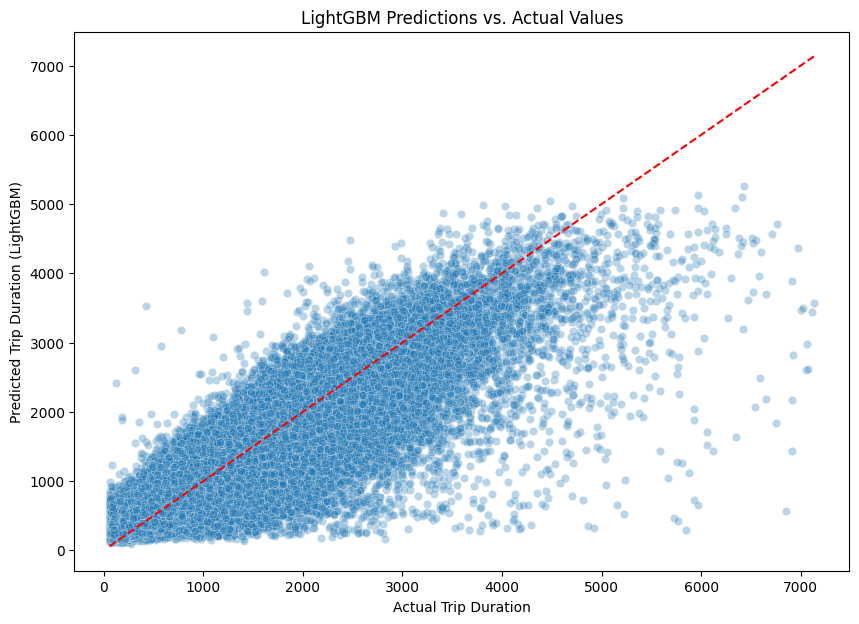

LightGBM RMSE: 298.0025719340519
LightGBM R2: 0.7903875437436568


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize LightGBM predictions
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_lgb, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect prediction line
plt.xlabel('Actual Trip Duration')
plt.ylabel('Predicted Trip Duration (LightGBM)')
plt.title('LightGBM Predictions vs. Actual Values')
plt.show()

print(f"LightGBM RMSE: {rmse_lgb}")
print(f"LightGBM R2: {r2_lgb}")

## Random Forest Modeli

Random Forest, birden fazla karar ağacının
birlikte çalıştığı bir ensemble yöntemidir.
Bu projede, LightGBM modeli ile karşılaştırma yapmak
ve stacking aşamasında kullanılmak üzere eğitilmiştir.


In [56]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest modeli
rf_model = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# Drop non-numeric columns and convert 'store_and_fwd_flag' to numerical
X_train_rf = X_train.drop(['id', 'pickup_datetime', 'dropoff_datetime'], axis=1)
X_test_rf = X_test.drop(['id', 'pickup_datetime', 'dropoff_datetime'], axis=1)

X_train_rf['store_and_fwd_flag'] = X_train_rf['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
X_test_rf['store_and_fwd_flag'] = X_test_rf['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

# Modeli eğit
rf_model.fit(X_train_rf, y_train)

# Test seti üzerinde tahmin
y_pred_rf = rf_model.predict(X_test_rf)

# Performans metrikleri
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)


Random Forest RMSE: 336.6720641536169
Random Forest R2: 0.7324584579926077


## Model Stacking

Model stacking, birden fazla modelin tahminlerini
bir meta-model aracılığıyla birleştiren bir ensemble yöntemidir.
Bu çalışmada LightGBM ve Random Forest modelleri
birlikte kullanılarak genel model performansının artırılması hedeflenmiştir.


In [57]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np # Import numpy for np.sqrt

# Var olan modelleri yakala
base_models = []

# Correctly add LightGBM model
if "lgb_model" in globals():
    base_models.append(("lgbm", lgb_model))

# Correctly add Random Forest model
if "rf_model" in globals():
    base_models.append(("rf", rf_model))

# Güvenlik kontrolü
if len(base_models) < 2:
    raise ValueError("Stacking için iki model bulunamadı.")

# Create preprocessed X_train and X_test for stacking
X_train_stack = X_train.drop(['id', 'pickup_datetime', 'dropoff_datetime'], axis=1)
X_test_stack = X_test.drop(['id', 'pickup_datetime', 'dropoff_datetime'], axis=1)

X_train_stack['store_and_fwd_flag'] = X_train_stack['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
X_test_stack['store_and_fwd_flag'] = X_test_stack['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(),
    cv=2,
    n_jobs=-1
)

# Modeli eğit using the preprocessed data
stack_model.fit(X_train_stack, y_train)

# Test seti üzerinde tahmin using the preprocessed data
y_pred_stack = stack_model.predict(X_test_stack)

# Performans metrikleri
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
r2_stack = r2_score(y_test, y_pred_stack)

print("Stacking RMSE:", rmse_stack)
print("Stacking R2:", r2_stack)


Stacking RMSE: 296.70094400522504
Stacking R2: 0.7922146526188623


## Sonuç

Bu projede, vize aşamasında hazırlanan veri seti kullanılarak
LightGBM ve Random Forest modelleri eğitilmiş,
ardından bu modeller stacking yöntemi ile birleştirilmiştir.
Elde edilen sonuçlar, stacking yaklaşımının
tekil modellere kıyasla daha yüksek genel performans sağladığını göstermiştir.
Proje bu aşamada başarıyla tamamlanmıştır.
